In [4]:
#Importation des bibliotheques
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
#Chargement du dataset breast_cancer
disease=datasets.load_breast_cancer()
X=pd.DataFrame(disease.data,columns=disease.feature_names)
Y=pd.Series(disease.target,name="classe")
X.head(),Y.head()



(   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0        17.99         10.38          122.80     1001.0          0.11840   
 1        20.57         17.77          132.90     1326.0          0.08474   
 2        19.69         21.25          130.00     1203.0          0.10960   
 3        11.42         20.38           77.58      386.1          0.14250   
 4        20.29         14.34          135.10     1297.0          0.10030   
 
    mean compactness  mean concavity  mean concave points  mean symmetry  \
 0           0.27760          0.3001              0.14710         0.2419   
 1           0.07864          0.0869              0.07017         0.1812   
 2           0.15990          0.1974              0.12790         0.2069   
 3           0.28390          0.2414              0.10520         0.2597   
 4           0.13280          0.1980              0.10430         0.1809   
 
    mean fractal dimension  ...  worst radius  worst texture  worst perimeter 

In [6]:
#Exploration du jeu de données
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
#Separation train/test
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.2,random_state=42)
#Normalisation des données
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Accuracy: 0.956140350877193
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



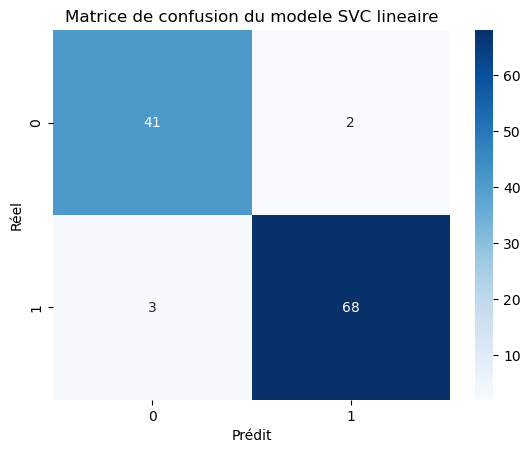

In [8]:
#Entrainement du modele SVC lineaire
svm_linear=SVC(kernel='linear')
svm_linear.fit(X_train_scaled,Y_train)
#Prédictions pour le modele SVC lineaire
Y_pred_linear=svm_linear.predict(X_test_scaled)
#Evaluation du modele SVC lineaire
print("Accuracy:",accuracy_score(Y_test,Y_pred_linear))
print("Classification report:")
print(classification_report(Y_test,Y_pred_linear))
#Matrice de confusion du modele SVC lineaire
cm_linear=confusion_matrix(Y_test,Y_pred_linear)
sns.heatmap(cm_linear,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion du modele SVC lineaire")
plt.show()


Accuracy: 0.868421052631579
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.65      0.79        43
           1       0.83      1.00      0.90        71

    accuracy                           0.87       114
   macro avg       0.91      0.83      0.85       114
weighted avg       0.89      0.87      0.86       114



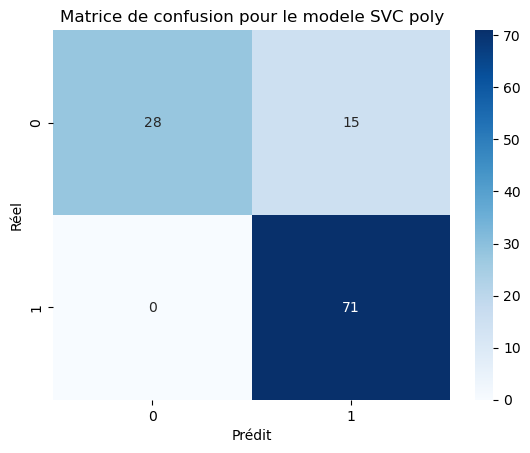

In [9]:
#Entrainement du modele SVC poly
svm_poly=SVC(kernel='poly',degree=3)
svm_poly.fit(X_train_scaled,Y_train)
#Prediction du modele SVC poly
Y_pred_poly=svm_poly.predict(X_test_scaled)
#Evaluation du modele SVC poly
print("Accuracy:",accuracy_score(Y_test,Y_pred_poly))
print("Classification report:")
print(classification_report(Y_test,Y_pred_poly))
#Matrice de confusion pour le modele SVC poly
cm_poly=confusion_matrix(Y_test,Y_pred_poly)
sns.heatmap(cm_poly,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour le modele SVC poly")
plt.show()



Accuracy:: 0.9824561403508771
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



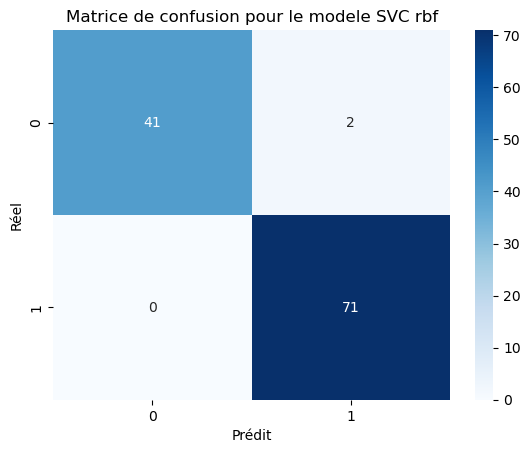

In [10]:
#Entrainement du modele SVC rbf
svm_rbf=SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled,Y_train)
#Prédiction pour le modele SVC rbf
Y_pred_rbf=svm_rbf.predict(X_test_scaled)
#Evaluation pour le modele SVC rbf
print("Accuracy::",accuracy_score(Y_test,Y_pred_rbf))
print("Classification report:")
print(classification_report(Y_test,Y_pred_rbf))
#Matrice de confusion pour le modele SVC rbf
cm_rbf=confusion_matrix(Y_test,Y_pred_rbf)
sns.heatmap(cm_rbf,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion pour le modele SVC rbf")
plt.show()



In [14]:
#GridSearchCV
param_grid=[
    {'kernel':['linear'],'C':[0.1,1,10]},
    {'kernel':['poly'],'C':[0.1,1,10],'degree':[2,3,4]},
    {'kernel':['rbf'],'C':[0.1,1,10],'gamma':['scale',0.1,0.01]}]
grid=GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy')
#grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled,Y_train)
print("Best Parameters:",grid.best_params_)
print("Best CV score:",grid.best_score_)
Y_predict_best=grid.predict(X_test_scaled)
print("Best accuracy:",accuracy_score(Y_test,Y_predict_best))


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9758241758241759
Best accuracy: 0.9824561403508771
